<a href="https://colab.research.google.com/github/tanviupadhyay1517/machine-learning-data-preparation-eda/blob/main/Data_Preparation_%26_EDA_Loan_Application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bank Loan Repayment**

You have joined the credit-risk analytics team of a retail bank. Management wants an early-warning model that predicts whether a loan applicant will default.

The team pulled 18 months of loan applications (January 2024 – June 2025) from three legacy systems into a single Excel export. As often happens, the export is messy.

Before any model can be trusted you must clean the data, prepare it for machine learning, and explore it to understand what drives default.

[**Data**: Loan_Applications.xlsx]

# Importing Libraries

In [ ]:
import pandas as pd

# Loading Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/ML Data Cleaning /Loan_Applications.xlsx')

# DATA UNDERSTANDING

In [ ]:
# Clean leading/trailing spaces from column headers
df.columns = df.columns.str.strip()

In [ ]:
# Total number of rows and columns
df.shape

(1254, 21)

In [ ]:
# Column Information & Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Application_ID        1254 non-null   object 
 1   Application_Date      1250 non-null   object 
 2   Customer_Name         1241 non-null   object 
 3   Gender                1230 non-null   object 
 4   Age                   1215 non-null   object 
 5   city                  1234 non-null   object 
 6   Education             1210 non-null   object 
 7   Employment_Type       1228 non-null   object 
 8   Annual_Income         1161 non-null   object 
 9   Co_Applicant_Income   416 non-null    object 
 10  Loan_Purpose          1242 non-null   object 
 11  Loan_Amount           1230 non-null   object 
 12  Loan_Tenure_Months    1236 non-null   object 
 13  Interest_Rate_Pct     1222 non-null   object 
 14  Credit_Score          1192 non-null   object 
 15  Existing_Monthly_EMI 

In [ ]:
#  First 5 Rows of Data
df.head()

,Application_ID,Application_Date,Customer_Name,Gender,Age,city,Education,Employment_Type,Annual_Income,Co_Applicant_Income,...,Loan_Amount,Loan_Tenure_Months,Interest_Rate_Pct,Credit_Score,Existing_Monthly_EMI,Num_Dependents,Avg_Monthly_Balance,Referral_Source,Internal_Notes,Defaulted
0,LN10001,2024-01-01 00:00:00,Jignesh Nair,MALE,28,Ahmedabad,High School,Business Owner,"₹8,84,000","₹8,58,000",...,"₹21,60,000",84,11.05,722,0,1,217914.0,online,NaN,No
1,LN10002,2024-01-02 00:00:00,Yash Sharma,Male,47,A'bad,Diploma,Business Owner,Rs. 824000,1588000,...,1870000,300,10.85,581,0,0,88043.0,Agent,NaN,No
2,LN10003,2024-01-03 00:00:00,Sneha Rao,Female,52,Rajkot,Graduate,Business Owner,"₹9,15,000","₹9,08,000",...,1580000,60,13.4,638,0,2,56747.0,Branch Walk-in,NaN,No
3,LN10490,2024-10-01 00:00:00,Yash Shah,Male,24,NaN,Post Graduate,Salaried,560000,451000,...,Rs.420000,84,10.6,643,0,0,NaN,NaN,NaN,1
4,LN10004,2024-01-04 00:00:00,Isha Vyas,Female,45,rajkot,Post Graduate,Self-Employed,NaN,"₹12,78,000",...,Rs.2770000,84,NaN,776,0,1,58581.0,existing customer,NaN,No


In [ ]:
# Summary of all columns (numeric and categorical)
df.describe(include='all')

,Application_ID,Application_Date,Customer_Name,Gender,Age,city,Education,Employment_Type,Annual_Income,Co_Applicant_Income,...,Loan_Amount,Loan_Tenure_Months,Interest_Rate_Pct,Credit_Score,Existing_Monthly_EMI,Num_Dependents,Avg_Monthly_Balance,Referral_Source,Internal_Notes,Defaulted
count,1254,1250,1241,1230,1215.0,1234,1210,1228,1161,416,...,1230.0,1236.0,1222.00,1192.0,1229.0,1229.0,1.216000e+03,1105,46,1248
unique,1200,595,708,13,60.0,34,22,14,958,375,...,591.0,17.0,247.00,243.0,377.0,7.0,NaN,14,5,12
top,LN11097,2024-10-30 00:00:00,Amit Shah,Male,38.0,Ahmedabad,Graduate,Salaried,-,"₹13,31,000",...,130000.0,60.0,9.85,679.0,0.0,1.0,NaN,Online,verified,No
freq,2,10,8,476,60.0,282,376,571,6,3,...,15.0,218.0,17.00,17.0,456.0,444.0,NaN,275,16,752
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6.433751e+04,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.789095e+05,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.394300e+04,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.214900e+04,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.112700e+04,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6.842875e+04,NaN,NaN,NaN


In [ ]:
# Print every distinct value in the 'city' column
print(df['city'].unique())

['Ahmedabad' "A'bad" 'Rajkot' nan 'rajkot' 'Pune' 'AHMEDABAD' 'Surat'
 'Bengaluru' 'Mumbai' 'Bombay' 'Ahmadabad' 'Vadodara' 'pune' 'Baroda'
 'Delhi' 'Vadodara ' 'New Delhi' 'SURAT' 'surat' 'Rajkot ' 'RAJKOT'
 'Pune ' 'delhi' 'bengaluru' 'PUNE' 'Ahmedabad ' 'MUMBAI' 'Bangalore'
 'Surat ' 'ahmedabad' 'mumbai' 'vadodara' 'VADODARA' 'BENGALURU']


In [ ]:
# Count occurrences of each entry (including missing NaN values)
print(df['city'].value_counts(dropna=False))

city
Ahmedabad     282
Surat         130
Vadodara      122
Rajkot        117
Mumbai         94
Pune           84
Delhi          79
Bengaluru      58
Ahmadabad      23
SURAT          20
NaN            20
AHMEDABAD      16
rajkot         16
Pune           16
Ahmedabad      14
ahmedabad      13
Surat          13
New Delhi      13
A'bad          12
Bombay         12
bengaluru      10
Vadodara       10
MUMBAI         10
Rajkot         10
surat          10
pune            9
Baroda          9
delhi           9
Bangalore       7
RAJKOT          5
mumbai          4
vadodara        3
PUNE            2
VADODARA        1
BENGALURU       1
Name: count, dtype: int64


In [ ]:
# Count occurrences of each entry (including missing NaN values)
print(df['Loan_Purpose'].value_counts(dropna=False))

Loan_Purpose
Home              258
Personal          245
Business          171
Car               164
Education         134
personal           42
Personal Loan      35
Business Loan      29
business           24
Home Loan          21
home loan          17
home               16
Housing            15
Auto               15
Car Loan           14
Edu Loan           13
car                13
NaN                12
education          11
Education Loan      5
Name: count, dtype: int64


In [ ]:
# Count occurrences of each entry (including missing NaN values)
print(df['Defaulted'].value_counts(dropna=False))

Defaulted
No     752
no      86
0       83
Yes     82
NO      72
N       69
0       67
yes      9
1        8
Y        8
1        7
NaN      6
YES      5
Name: count, dtype: int64


# DATA CLEANING (REMOVING METADATA & DUPLICATES)

In [ ]:
# Drop irrelevant columns that are not predictive for ML models
# errors='ignore' tells pandas not to raise an error if any of the specified column names are missing from the DataFrame.
df = df.drop(columns=['Internal_Notes', 'Customer_Name', 'Application_Date'], errors='ignore')

In [ ]:
# Remove duplicate rows based on unique Application_ID
df = df.drop_duplicates(subset=['Application_ID'], keep='first')

# DATA TYPE CORRECTION & TEXT CLEANING

In [ ]:
# Clean Numeric Columns (Strip currency symbols ₹, Rs., commas, %, and invalid strings)
numeric_columns = [
    'Age', 'Annual_Income', 'Co_Applicant_Income', 'Loan_Amount',
    'Loan_Tenure_Months', 'Interest_Rate_Pct', 'Credit_Score',
    'Existing_Monthly_EMI', 'Num_Dependents', 'Avg_Monthly_Balance'
]

for col in numeric_columns:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace('₹', '')
    df[col] = df[col].str.replace('Rs.', '')
    df[col] = df[col].str.replace('Rs', '')
    df[col] = df[col].str.replace(',', '')
    df[col] = df[col].str.replace('%', '')
    df[col] = df[col].str.strip()

# Convert invalid text (like '-', 'N/A') into missing values (NaN) and valid text into numbers
# errors='coerce' tells pandas to convert any invalid value that cannot be turned into a number into NaN (missing value) instead of crashing or leaving it as text.
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# Clean Target Variable ('Defaulted')
df['Defaulted'] = df['Defaulted'].astype(str).str.strip().str.upper()

# Step 1: Standardize ALL variations into 'NO' or 'YES'
df['Defaulted'] = df['Defaulted'].replace({
    '0': 'NO', '0.0': 'NO', 'N': 'NO',
    '1': 'YES', '1.0': 'YES', 'Y': 'YES',
    'NAN': None, 'NONE': None
})

# Step 2: Map 'NO' to 0 and 'YES' to 1
df['Defaulted'] = df['Defaulted'].map({'NO': 0, 'YES': 1})

# Step 3: Drop missing target rows
df = df.dropna(subset=['Defaulted'])

In [ ]:
# Standardize Text Formatting in Categorical Columns
categorical_columns = ['Gender', 'city', 'Education', 'Employment_Type', 'Loan_Purpose', 'Referral_Source']
for col in categorical_columns:

    # Standardize to Proper Title Case and strip extra spaces
    df[col] = df[col].astype(str).str.strip().str.title()

    # Replace placeholder text with true Python missing values (None)
    df[col] = df[col].replace({'Nan': None, 'None': None, 'Null': None, '?': None, '-': None})

In [ ]:
# Fix Inconsistent Categorical Spellings and Variations
df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'F': 'Female'
})

df['city'] = df['city'].replace({
    "A'Bad": "Ahmedabad",
    "Ahmadabad": "Ahmedabad",
    "Amdavad": "Ahmedabad",
    "Bnk": "Bangalore",
    "Bengaluru": "Bangalore",
    "Bombay": "Mumbai",
    "Baroda": "Vadodara"
})

df['Education'] = df['Education'].replace({
    'Hs': 'High School',
    'Highschool': 'High School',
    '12Th': 'High School',
    'Pg': 'Post Graduate',
    'Grad': 'Graduate',
    'Bachelors': "Bachelor's",
    'Masters': "Master's",
    'Dip.': 'Diploma',
    'Ug': 'Graduate',
    'Ph.D': 'Doctorate',
    'Phd': 'Doctorate'
})

df['Employment_Type'] = df['Employment_Type'].replace({
    'Businessowner': 'Business Owner',
    'Businessman': 'Business Owner',
    'Self Employed': 'Self-Employed'
})

df['Loan_Purpose'] = df['Loan_Purpose'].replace({
    'Business Loan': 'Business',
    'Home Loan': 'Home',
    'Housing': 'Home',
    'Auto': 'Car',
    'Car Loan': 'Car',
    'Edu Loan': 'Education',
    'Education Loan': 'Education',
    'Personal Loan': 'Personal'
})

df['Referral_Source'] = df['Referral_Source'].replace({
    'Branch Walk-In': 'Walk-In',
    'Branch': 'Walk-In'
})

# OUTLIER & NOISY DATA HANDLING

In [ ]:
# Logical Outliers: Mark impossible entries as missing (None)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = None
df.loc[(df['Credit_Score'] < 300) | (df['Credit_Score'] > 900), 'Credit_Score'] = None
df.loc[df['Avg_Monthly_Balance'] < 0, 'Avg_Monthly_Balance'] = None

In [ ]:
# Extreme Outliers: Cap upper values at 99th percentile (Capping/Winsorization)
income_99th = df['Annual_Income'].quantile(0.99)
df['Annual_Income'] = df['Annual_Income'].clip(upper=income_99th)

loan_99th = df['Loan_Amount'].quantile(0.99)
df['Loan_Amount'] = df['Loan_Amount'].clip(upper=loan_99th)

# MISSING VALUE IMPUTATION

In [ ]:
# Detect missing values
df.isnull().sum()
df.isnull().mean()*100

,0
Application_ID,0.000000
Gender,2.010050
Age,4.690117
city,1.507538
Education,4.020101
Employment_Type,1.926298
Annual_Income,8.123953
Co_Applicant_Income,66.582915
Loan_Purpose,1.005025
Loan_Amount,2.512563


In [ ]:
# Domain Logic: Missing Co_Applicant_Income means 0 extra income
df['Co_Applicant_Income'] = df['Co_Applicant_Income'].fillna(0)

In [ ]:
# Continuous Numerical Columns: Fill missing entries with Median
for col in numeric_columns:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [ ]:
# Categorical Columns: Fill missing entries with Mode (Most Frequent)
for col in categorical_columns:
    most_frequent = df[col].mode()[0]
    df[col] = df[col].fillna(most_frequent)

In [ ]:
# Checking missing values if its treatment
df.isnull().sum()
df.isnull().mean()*100

,0
Application_ID,0.0
Gender,0.0
Age,0.0
city,0.0
Education,0.0
Employment_Type,0.0
Annual_Income,0.0
Co_Applicant_Income,0.0
Loan_Purpose,0.0
Loan_Amount,0.0


# PREPROCESSING (ENCODING & STANDARDIZATION)

In [ ]:
# One-Hot Encoding: Convert text categories into binary (0/1) columns
encoded_categories = pd.get_dummies(df[categorical_columns], drop_first=True, dtype=int)

In [ ]:
# Standardization: Scale continuous numerical columns to Mean = 0, Std Dev = 1
scaled_numbers = pd.DataFrame(index=df.index)

for col in numeric_columns:
    col_mean = df[col].mean()
    col_std = df[col].std()
    # Z-score formula: (X - Mean) / Std
    scaled_numbers[col] = (df[col] - col_mean) / col_std

**OR**

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit and transform the numerical columns
# (Computes mean & std on numeric_columns, then scales them)
scaled_numbers = pd.DataFrame(
    scaler.fit_transform(df[numeric_columns]),
    columns=numeric_columns,
    index=df.index
)

In [ ]:
# Combine processed components into final ML dataset
final_df = pd.concat([df[['Application_ID']], scaled_numbers, encoded_categories, df[['Defaulted']]], axis=1)

# VERIFICATION & SUMMARY

In [ ]:
print("Final Cleaned Dataset Shape:", final_df.shape)
print("Total Missing Values Remaining:", final_df.isnull().sum().sum())
print(final_df.head())

Final Cleaned Dataset Shape: (1194, 42)
Total Missing Values Remaining: 0
  Application_ID       Age  Annual_Income  Co_Applicant_Income  Loan_Amount  \
0        LN10001 -1.073446       0.035753             1.267577     0.511921   
1        LN10002  1.160086      -0.086569             2.786986     0.315676   
2        LN10003  1.747857       0.098953             1.371646     0.119430   
3        LN10490 -1.543663      -0.624785             0.420455    -0.665552   
4        LN10004  0.924977      -0.182387             2.141758     0.924714   

   Loan_Tenure_Months  Interest_Rate_Pct  Credit_Score  Existing_Monthly_EMI  \
0           -0.121170           0.029930      0.584479             -0.802646   
1            2.545679          -0.007283     -2.166644             -0.802646   
2           -0.417486           0.467189     -1.054488             -0.802646   
3           -0.121170          -0.053800     -0.956930             -0.802646   
4           -0.121170          -0.072407      1.638

In [ ]:
# Check exact target distribution ratio
print(df['Defaulted'].value_counts(normalize=True) * 100)

Defaulted
0.0    90.619765
1.0     9.380235
Name: proportion, dtype: float64


# Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

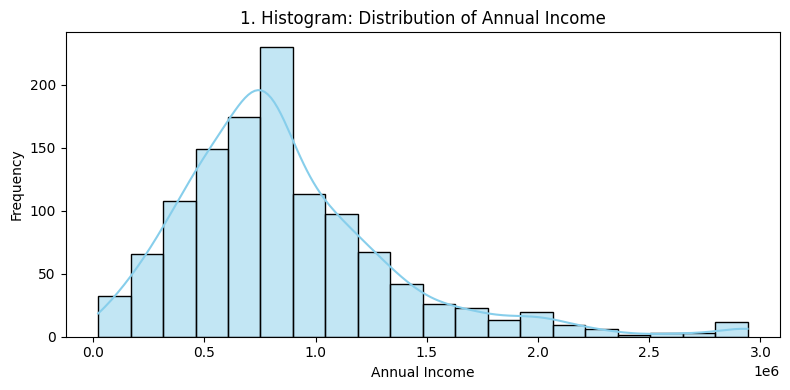

In [ ]:
# Histogram: Shows the frequency distribution and skewness of a numeric column
plt.figure(figsize=(8, 4))
sns.histplot(df['Annual_Income'], kde=True, color='skyblue', bins=20)
plt.title('Histogram: Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

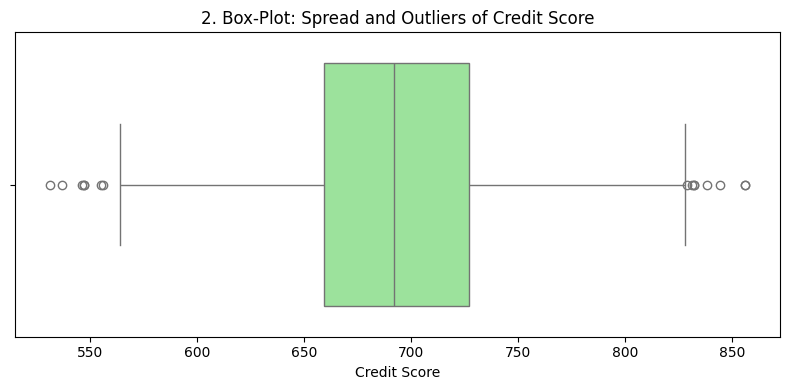

In [ ]:
# Box-Plot: Shows summary statistics (Median, IQR) and identifies outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Credit_Score'], color='lightgreen')
plt.title('Box-Plot: Spread and Outliers of Credit Score')
plt.xlabel('Credit Score')
plt.tight_layout()
plt.show()

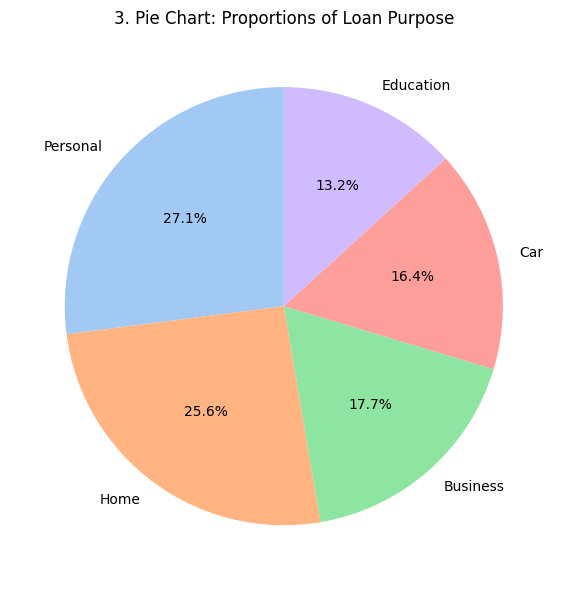

In [ ]:
# Pie Chart: Shows proportions/percentages of a categorical variable
plt.figure(figsize=(6, 6))
df['Loan_Purpose'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)
plt.title('Pie Chart: Proportions of Loan Purpose')
plt.ylabel('')  # Hides default pandas label
plt.tight_layout()
plt.show()

/tmp/ipykernel_4632/3811521123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education', data=df, palette='Blues_d')


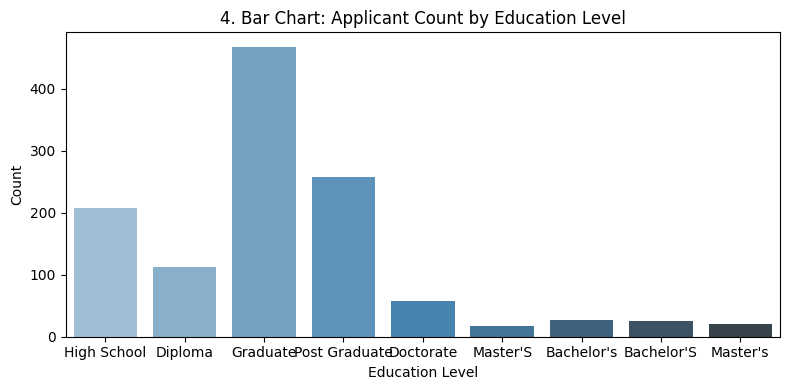

In [ ]:
# Bar Chart: Shows absolute counts across categories
plt.figure(figsize=(8, 4))
sns.countplot(x='Education', data=df, palette='Blues_d')
plt.title('Bar Chart: Applicant Count by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

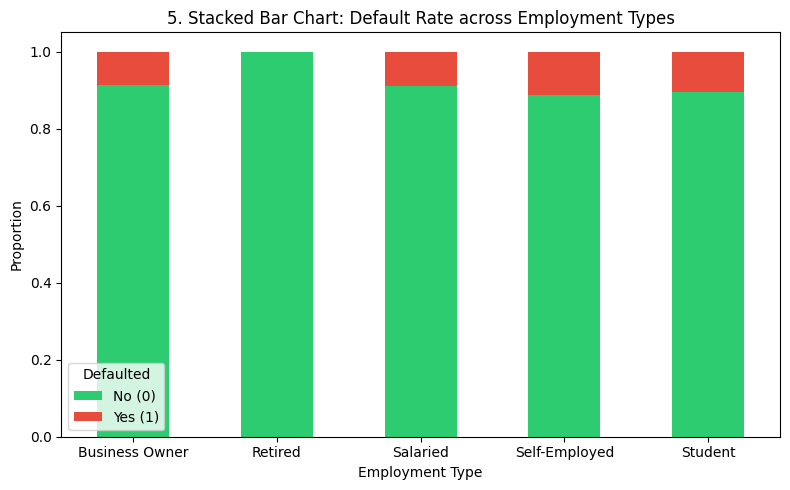

In [ ]:
# Stacked Bar Chart: Compares proportion of Defaulted (y) across Employment Types
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df['Employment_Type'], df['Defaulted'], normalize='index')
cross_tab.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(8, 5))
plt.title('Stacked Bar Chart: Default Rate across Employment Types')
plt.xlabel('Employment Type')
plt.ylabel('Proportion')
plt.legend(title='Defaulted', labels=['No (0)', 'Yes (1)'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

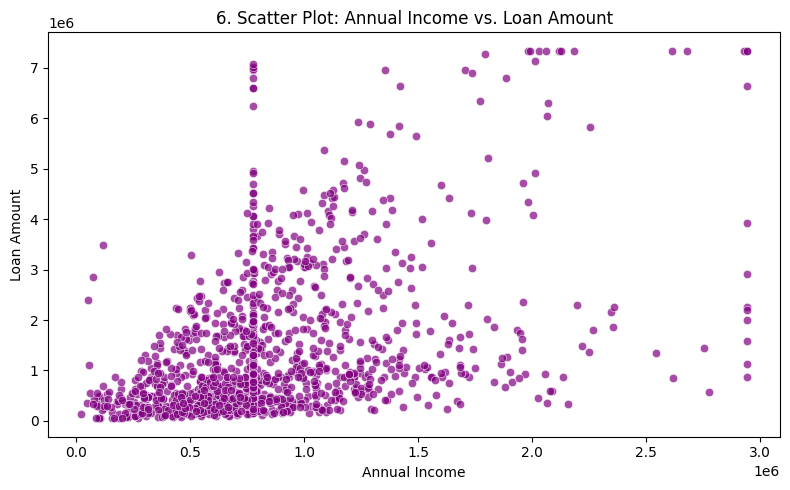

In [ ]:
# Scatter Plot: Shows relationship and correlation pattern between two numeric features
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Annual_Income', y='Loan_Amount', data=df, alpha=0.7, color='purple')
plt.title('Scatter Plot: Annual Income vs. Loan Amount')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4632/3086479306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Defaulted', y='Credit_Score', data=df, palette=['#2ecc71', '#e74c3c'])


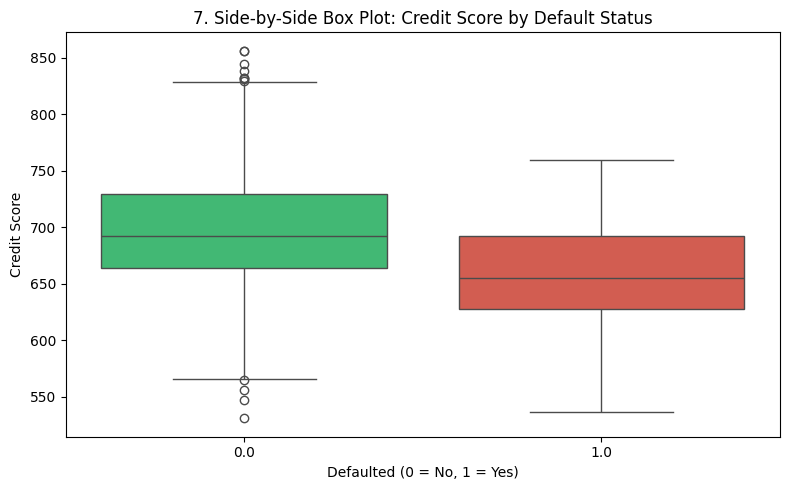

In [ ]:
# Side-by-Side Box Plot: Compares numeric distributions across distinct categories
plt.figure(figsize=(8, 5))
sns.boxplot(x='Defaulted', y='Credit_Score', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Side-by-Side Box Plot: Credit Score by Default Status')
plt.xlabel('Defaulted (0 = No, 1 = Yes)')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

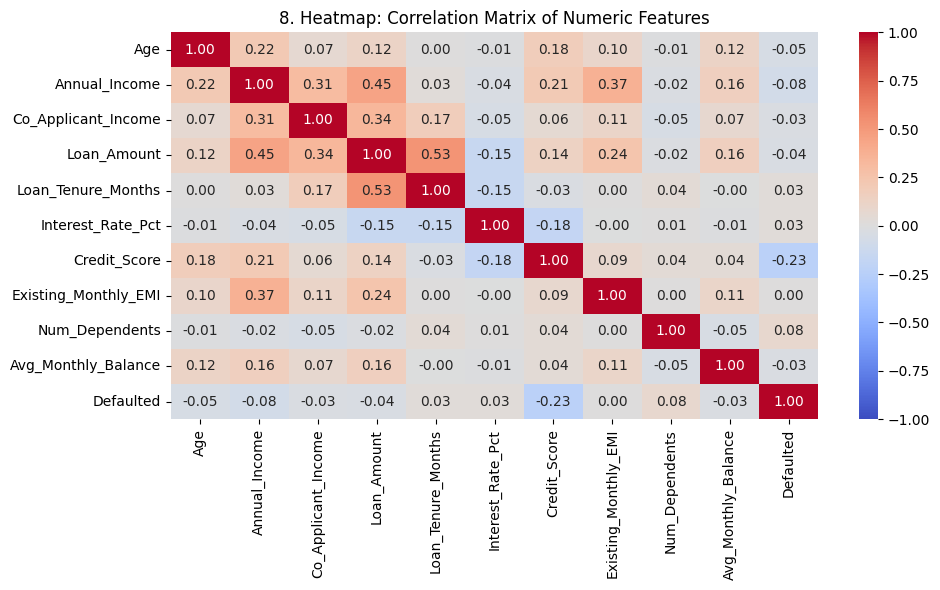

In [ ]:
# Heatmap: Shows strength of linear relationships between all numeric variables
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap: Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()